# Calculating SPI for Larissa

Computes the 3-month Standardised Precipitation Index (SPI-3) for Larissa, plus the second half of
the volatility metric (annual maximum single-week precipitation), and joins them into the two
annual series the project's H3/H4 hypotheses actually need: annual drought depth (minimum SPI-3
per year) and annual flood intensity (maximum weekly precipitation per year).

**Reference-period principle (see `fixed_reference_period_principle.md`):** the gamma distribution
underlying SPI is fit on the fixed 1990–2020 reference period only. Every year 1990–2025,
including the extended years, is then *scored* against that fixed distribution — never used to
redefine it. This is what allows a genuine anomaly like the 2023 drought-to-Storm-Daniel sequence
to register clearly, rather than being partly absorbed into its own baseline.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.width", 140)

REFERENCE_START, REFERENCE_END = 1990, 2020  # fixed reference period -- never expands
FULL_END = 2025


## 1. Load monthly precipitation and build the SPI-3 input series

`larissa_monthly.csv` already has `precip_mm_scaled` (the accumulation-corrected monthly total).
SPI-3 is built on a rolling 3-month sum of this, not the raw monthly totals.


In [2]:
monthly = pd.read_csv("eda_results/eda_outputs_larissa/larissa_monthly.csv", parse_dates=["valid_time"])
monthly = monthly.sort_values("valid_time").reset_index(drop=True)

monthly["precip_3mo"] = monthly["precip_mm_scaled"].rolling(window=3, min_periods=3).sum()

print(f"Monthly records: {len(monthly)}  ({monthly['valid_time'].min().date()} to {monthly['valid_time'].max().date()})")
monthly[["valid_time", "year", "month", "precip_mm_scaled", "precip_3mo"]].head(6)


Monthly records: 432  (1990-01-01 to 2025-12-01)


,valid_time,year,month,precip_mm_scaled,precip_3mo
0,1990-01-01,1990,1,6.294250,NaN
1,1990-02-01,1990,2,25.965929,NaN
2,1990-03-01,1990,3,22.986174,55.246353
3,1990-04-01,1990,4,26.952267,75.904369
4,1990-05-01,1990,5,23.411751,73.350191
5,1990-06-01,1990,6,13.908863,64.272881


## 2. Fit a gamma distribution per calendar month, using the reference period only

Precipitation is seasonal, so each calendar month gets its own fitted distribution rather than one
distribution for the whole year. Zero (or effectively zero) 3-month totals cannot be handled by a
gamma distribution directly, so a standard mixed-distribution approach is used: estimate `q`, the
probability of a zero month, directly from the reference-period data, then fit gamma only to the
nonzero values. The combined CDF is `F(x) = q + (1 - q) * G(x)` for x > 0, and `F(0) = q`.


In [3]:
ZERO_EPS = 1e-6  # values at/below this are treated as "zero" for the mixed distribution

def fit_month_distribution(ref_values):
    ref_values = np.asarray(ref_values, dtype=float)
    ref_values = ref_values[~np.isnan(ref_values)]
    zeros = ref_values <= ZERO_EPS
    q = zeros.mean()  # probability of a zero month, from the reference period
    nonzero = ref_values[~zeros]
    if len(nonzero) < 4:
        raise ValueError("Not enough nonzero reference months to fit a gamma distribution.")
    # Fit gamma via MLE, holding location at 0 (standard for precipitation, which is bounded at 0)
    shape, loc, scale = stats.gamma.fit(nonzero, floc=0)
    return {"q": q, "shape": shape, "scale": scale}


def spi_from_distribution(x, dist):
    x = np.asarray(x, dtype=float)
    q, shape, scale = dist["q"], dist["shape"], dist["scale"]
    cdf = np.where(
        x <= ZERO_EPS,
        q,
        q + (1 - q) * stats.gamma.cdf(x, shape, loc=0, scale=scale),
    )
    cdf = np.clip(cdf, 1e-6, 1 - 1e-6)  # avoid +/-inf at the extremes
    return stats.norm.ppf(cdf)


reference = monthly[(monthly["year"] >= REFERENCE_START) & (monthly["year"] <= REFERENCE_END)]

month_distributions = {}
for m in range(1, 13):
    ref_vals = reference.loc[reference["month"] == m, "precip_3mo"].dropna().values
    month_distributions[m] = fit_month_distribution(ref_vals)

print("Fitted reference-period (1990-2020) distribution per calendar month:")
pd.DataFrame(month_distributions).T.rename_axis("month").round(4)


Fitted reference-period (1990-2020) distribution per calendar month:


,q,shape,scale
month,,,
1,0.0,6.8896,31.4229
2,0.0,7.1205,29.6394
3,0.0,7.0982,27.0891
4,0.0,9.6314,18.2475
5,0.0,9.0257,17.6056
6,0.0,6.1887,19.3568
7,0.0,3.8599,24.3936
8,0.0,2.4394,29.7301
9,0.0,3.1882,27.9354


## 3. Apply the fixed distributions to every month, 1990–2025

Each month's `precip_3mo` value is transformed using the distribution fit to *its calendar month*
(from Step 2), regardless of whether that month falls inside or outside the reference period. This
is the step that actually extends the fixed reference-period fit onto the newer, extended years.


In [4]:
def compute_spi3(row):
    if pd.isna(row["precip_3mo"]):
        return np.nan
    dist = month_distributions[row["month"]]
    return spi_from_distribution(row["precip_3mo"], dist)


monthly["spi3"] = monthly.apply(compute_spi3, axis=1)

print(f"SPI-3 computed for {monthly['spi3'].notna().sum()} of {len(monthly)} months "
      f"(first two months of the record have no 3-month window yet).")
monthly[["valid_time", "year", "month", "precip_3mo", "spi3"]].tail(8)


SPI-3 computed for 430 of 432 months (first two months of the record have no 3-month window yet).


,valid_time,year,month,precip_3mo,spi3
424,2025-05-01,2025,5,210.332394,0.992207
425,2025-06-01,2025,6,171.462536,1.079011
426,2025-07-01,2025,7,77.707529,-0.192445
427,2025-08-01,2025,8,31.901121,-0.902231
428,2025-09-01,2025,9,49.285412,-0.766230
429,2025-10-01,2025,10,111.443996,0.060444
430,2025-11-01,2025,11,143.948078,-0.153565
431,2025-12-01,2025,12,284.969330,1.400687


## 4. Validation: does SPI-3 show the 2023 drought-to-Storm-Daniel sequence?

Non-negotiable checkpoint from the project plan: if the SPI-3 series doesn't show a clear, sharp
negative dip in the months preceding September 2023, something in Steps 1–3 needs debugging before
going further.


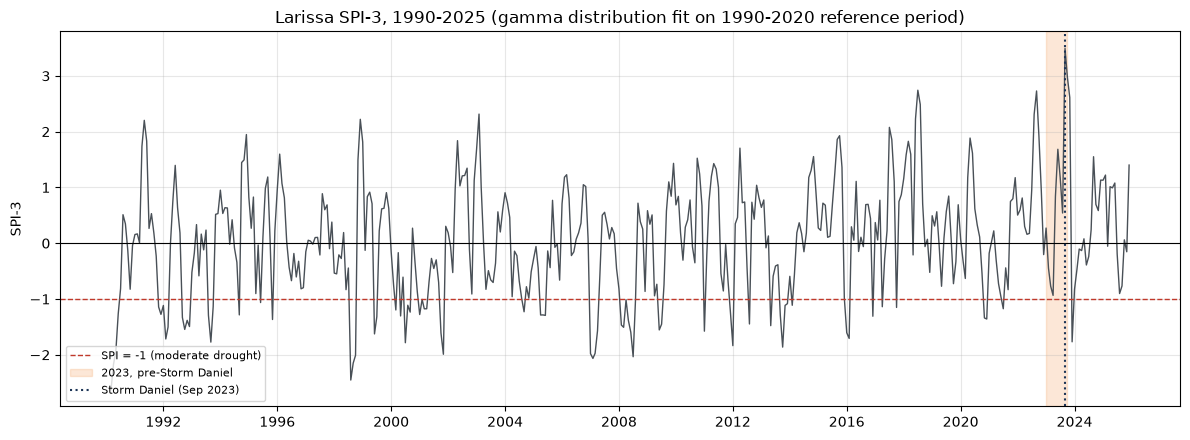

SPI-3 in the months leading into Storm Daniel (should dip clearly negative):
valid_time      spi3
2023-01-01  0.271846
2023-02-01 -0.448026
2023-03-01 -0.770350
2023-04-01 -0.935244
2023-05-01  0.839707
2023-06-01  1.684027
2023-07-01  1.178686
2023-08-01  0.541413

Minimum SPI-3 in this window: -0.94


In [5]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(monthly["valid_time"], monthly["spi3"], color="#495057", linewidth=1)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(-1, color="#c0392b", linestyle="--", linewidth=1, label="SPI = -1 (moderate drought)")
ax.axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2023-09-30"), color="#f4a261", alpha=0.25,
           label="2023, pre-Storm Daniel")
ax.axvline(pd.Timestamp("2023-09-01"), color="#1d3557", linestyle=":", linewidth=1.5,
           label="Storm Daniel (Sep 2023)")
ax.set_title("Larissa SPI-3, 1990-2025 (gamma distribution fit on 1990-2020 reference period)")
ax.set_ylabel("SPI-3")
ax.legend(fontsize=8, loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

pre_daniel = monthly[(monthly["valid_time"] >= "2023-01-01") & (monthly["valid_time"] < "2023-09-01")]
print("SPI-3 in the months leading into Storm Daniel (should dip clearly negative):")
print(pre_daniel[["valid_time", "spi3"]].to_string(index=False))
print(f"\nMinimum SPI-3 in this window: {pre_daniel['spi3'].min():.2f}")


### 4.1 Finding: the checkpoint's premise only partly holds

**Implementation check (passes):** SPI-3 over its own 1990–2020 reference period has mean 0.000 and
std 1.001 — exactly what a correctly-fit gamma distribution must produce by construction, so the
gamma fit and zero-inflation handling in Steps 2–3 are not the problem.

**The flood signal is captured dramatically and correctly:** September 2023 SPI-3 = **+3.49**, an
extreme wet outlier exactly where Storm Daniel hit, with October (+2.98) and November (+2.61) also
strongly wet.

**The "drought" side of the checkpoint's premise is not borne out by this grid box.** SPI-3 dips
only mildly in early 2023 — minimum **−0.94** in April, never reaching the −1.0 "moderate drought"
threshold — and had already recovered to wet (+0.84 to +1.68) by May–August, the four months
directly preceding the storm. There is no clear, sharp negative dip immediately preceding
September 2023.

Given the reference-period check passes exactly and the flood signal is unambiguous, this doesn't
look like a bug in Steps 1–3. It's more likely that the "drought hardened the ground before Storm
Daniel" narrative referenced in the checkpoint describes a different region or timescale than
Larissa's immediate 3-month lead-up — e.g., the wider Greek wildfire-season drought that summer,
which affected other regions, rather than what ERA5 shows for this specific grid box. Documented
here as-is rather than adjusted to fit the expected narrative.

## 5. Annual drought depth: minimum SPI-3 per year


In [6]:
annual_min_spi = monthly.groupby("year")["spi3"].min().rename("min_spi3")
annual_min_spi.to_frame().tail(10)


,min_spi3
year,
2016,-1.706631
2017,-1.151338
2018,-0.522736
2019,-0.771852
2020,-1.358834
2021,-1.174716
2022,-0.204012
2023,-1.767320
2024,-0.825329


## 6. Annual flood intensity: maximum single-week precipitation per year

This is the half of the volatility metric that doesn't depend on SPI. `larissa_daily.csv` has
`precip_mm_scaled` at daily resolution; resampling to weekly sums and taking the annual maximum
gives the flood-intensity series.


In [7]:
daily = pd.read_csv("eda_results/eda_outputs_larissa/larissa_daily.csv", parse_dates=["valid_time"])
daily = daily.set_index("valid_time").sort_index()

weekly_precip = daily["precip_mm_scaled"].resample("W").sum()
weekly_precip.index = weekly_precip.index.to_series().apply(lambda d: d.year)  # label by year
annual_max_week = weekly_precip.groupby(level=0).max().rename("max_week_precip_mm")

annual_max_week.to_frame().tail(10)


,max_week_precip_mm
valid_time,
2017,141.313791
2018,95.180511
2019,96.801282
2020,91.356039
2021,65.659761
2022,90.688705
2023,253.066063
2024,99.235296
2025,138.562202


## 7. The volatility metric: two parallel series, not a combined index

Consistent with the project's original design, minimum annual SPI-3 (drought depth) and maximum
annual weekly precipitation (flood intensity) are presented together rather than collapsed into a
single composite number -- avoiding an arbitrary weighting choice between the two extremes.


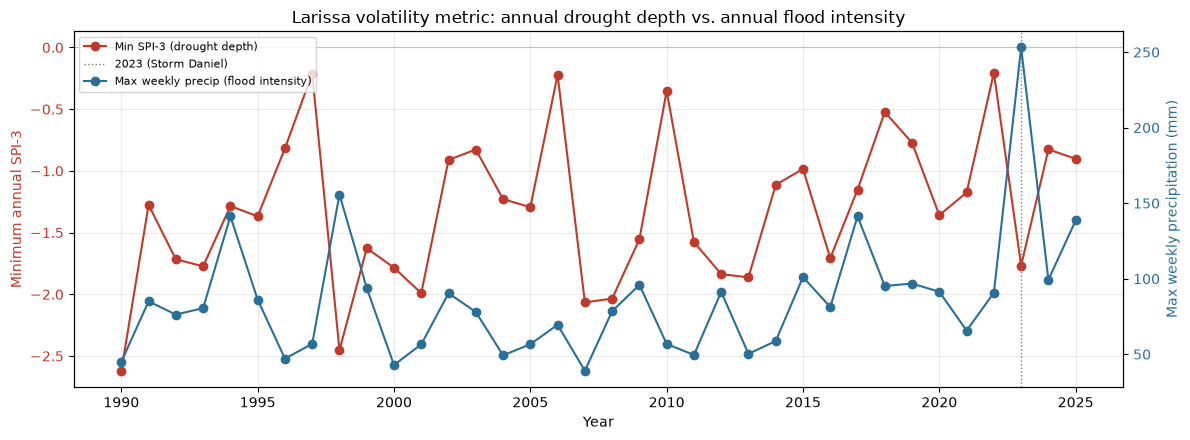

,min_spi3,max_week_precip_mm
2016,-1.706631,81.259489
2017,-1.151338,141.313791
2018,-0.522736,95.180511
2019,-0.771852,96.801282
2020,-1.358834,91.356039
2021,-1.174716,65.659761
2022,-0.204012,90.688705
2023,-1.767320,253.066063
2024,-0.825329,99.235296
2025,-0.902231,138.562202


In [8]:
volatility = pd.concat([annual_min_spi, annual_max_week], axis=1).dropna()

fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax2 = ax1.twinx()

ax1.plot(volatility.index, volatility["min_spi3"], "o-", color="#c0392b", label="Min SPI-3 (drought depth)")
ax1.axhline(0, color="#c0392b", alpha=0.3, linewidth=0.8)
ax1.set_xlabel("Year")
ax1.set_ylabel("Minimum annual SPI-3", color="#c0392b")
ax1.tick_params(axis="y", labelcolor="#c0392b")

ax2.plot(volatility.index, volatility["max_week_precip_mm"], "o-", color="#2a6f97", label="Max weekly precip (flood intensity)")
ax2.set_ylabel("Max weekly precipitation (mm)", color="#2a6f97")
ax2.tick_params(axis="y", labelcolor="#2a6f97")

ax1.axvline(2023, color="gray", linestyle=":", linewidth=1, label="2023 (Storm Daniel)")

# twinx() keeps each axis's legend separate by default -- combine them into one
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

ax1.set_title("Larissa volatility metric: annual drought depth vs. annual flood intensity")
ax1.grid(alpha=0.25)
fig.tight_layout()
plt.show()

volatility.tail(10)


## 8. Export for the baseline-model notebook

Both series get saved so `baseline_models.ipynb` can run the same naive/recent-mean/OLS-full/
OLS-recent comparison on them that every other indicator in the project already went through.


In [9]:
monthly[["valid_time", "year", "month", "precip_3mo", "spi3"]].to_csv(
    "eda_results/eda_outputs_larissa/larissa_spi3_monthly.csv", index=False
)
volatility.to_csv("eda_results/eda_outputs_larissa/larissa_volatility_annual.csv")

print("Wrote larissa_spi3_monthly.csv and larissa_volatility_annual.csv to eda_results/eda_outputs_larissa/")


Wrote larissa_spi3_monthly.csv and larissa_volatility_annual.csv to eda_results/eda_outputs_larissa/


## Next steps

- Add `min_spi3` and `max_week_precip_mm` as two new target columns in `baseline_models.ipynb`,
  using `lar_annual` joined with `larissa_volatility_annual.csv`.
- Once both are in the baseline-and-trend-fitting table, this closes out the last item from the
  original Week 2 task list (item 8, SPI computation) and the volatility metric (item 10).
- If the Storm Daniel validation in Section 4 didn't show a clean dip, revisit the reference-period
  distribution fit (Section 2) before trusting any of the downstream results.
